In [ ]:
!pip -q install scikit-learn

import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize

In [ ]:
# ✅ CHANGE ONLY THESE
TRAIN_DIR = "/content/drive/MyDrive/Capstone Dataset/Guava_Fruit_Dieases/Train"
TEST_DIR  = "/content/drive/MyDrive/Capstone Dataset/Guava_Fruit_Dieases/Test"

In [ ]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42
EPOCHS_HEAD = 5
EPOCHS_FINETUNE = 25
LR_HEAD = 1e-3
LR_FINETUNE = 1e-5

In [ ]:
# 4) Load Dataset (Already split: Train/Test)
#    -> Train folder = training set
#    -> Test folder  = validation set + also used as final test evaluation (as you requested)
# =========================
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=False
)

# Keep a deterministic copy for metrics (confusion matrix/ROC need fixed order)
test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=False
)

class_names = train_ds.class_names
num_classes = len(class_names)
print("Classes:", class_names)

# ✅ Safety: ensure TEST has same class order/names as TRAIN
if val_ds.class_names != class_names:
    raise ValueError(
        "Class name/order mismatch between Train and Test folders.\n"
        f"Train: {class_names}\nTest : {val_ds.class_names}\n"
        "Fix folder class subdirectory names so they match exactly."
    )

Found 3520 files belonging to 4 classes.
Found 880 files belonging to 4 classes.
Found 880 files belonging to 4 classes.
Classes: ['Anthracnose', 'Healthy', 'Scab', 'Styler end root']


In [ ]:
# 5) Data Pipeline Optimization
# =========================
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000, seed=SEED).prefetch(AUTOTUNE)
val_ds   = val_ds.cache().prefetch(AUTOTUNE)
test_ds  = test_ds.cache().prefetch(AUTOTUNE)

In [ ]:
# 6) Data Augmentation (train only)
# =========================
data_aug = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.2),
    layers.RandomBrightness(0.1),
], name="data_augmentation")

In [ ]:
# 7) Build Pretrained Model
# =========================
base = EfficientNetB0(include_top=False, weights="imagenet", input_shape=IMG_SIZE + (3,))
base.trainable = False

inputs = layers.Input(shape=IMG_SIZE + (3,))
x = data_aug(inputs)              # augmentation only affects training (Keras handles this automatically)
x = preprocess_input(x)
x = base(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.30)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)
model = models.Model(inputs, outputs)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
# 8) Train Head (Frozen base)
# =========================
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", patience=2, factor=0.5),
]

model.compile(
    optimizer=tf.keras.optimizers.Adam(LR_HEAD),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

h1 = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS_HEAD, callbacks=callbacks)

Epoch 1/5
110/110 ━━━━━━━━━━━━━━━━━━━━ 1265s 3s/step - accuracy: 0.5296 - loss: 1.1012 - val_accuracy: 0.6477 - val_loss: 0.9407 - learning_rate: 0.0010
Epoch 2/5
110/110 ━━━━━━━━━━━━━━━━━━━━ 10s 94ms/step - accuracy: 0.7074 - loss: 0.7359 - val_accuracy: 0.6591 - val_loss: 0.8654 - learning_rate: 0.0010
Epoch 3/5
110/110 ━━━━━━━━━━━━━━━━━━━━ 10s 95ms/step - accuracy: 0.7433 - loss: 0.6440 - val_accuracy: 0.6455 - val_loss: 0.9383 - learning_rate: 0.0010
Epoch 4/5
110/110 ━━━━━━━━━━━━━━━━━━━━ 10s 94ms/step - accuracy: 0.7490 - loss: 0.6159 - val_accuracy: 0.6205 - val_loss: 0.9628 - learning_rate: 0.0010
Epoch 5/5
110/110 ━━━━━━━━━━━━━━━━━━━━ 11s 96ms/step - accuracy: 0.7785 - loss: 0.5679 - val_accuracy: 0.6386 - val_loss: 0.9442 - learning_rate: 5.0000e-04


In [ ]:
# 9) Fine-tuning (Unfreeze last layers)
# =========================
base.trainable = True
for layer in base.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(LR_FINETUNE),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

h2 = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS_FINETUNE, callbacks=callbacks)

Epoch 1/25
110/110 ━━━━━━━━━━━━━━━━━━━━ 28s 133ms/step - accuracy: 0.6430 - loss: 0.8782 - val_accuracy: 0.6057 - val_loss: 0.9428 - learning_rate: 1.0000e-05
Epoch 2/25
110/110 ━━━━━━━━━━━━━━━━━━━━ 12s 110ms/step - accuracy: 0.7159 - loss: 0.7345 - val_accuracy: 0.6205 - val_loss: 0.9478 - learning_rate: 1.0000e-05
Epoch 3/25
110/110 ━━━━━━━━━━━━━━━━━━━━ 12s 110ms/step - accuracy: 0.7400 - loss: 0.6987 - val_accuracy: 0.6273 - val_loss: 0.9844 - learning_rate: 1.0000e-05
Epoch 4/25
110/110 ━━━━━━━━━━━━━━━━━━━━ 12s 110ms/step - accuracy: 0.7621 - loss: 0.6390 - val_accuracy: 0.6295 - val_loss: 0.9969 - learning_rate: 5.0000e-06
Epoch 5/25
110/110 ━━━━━━━━━━━━━━━━━━━━ 12s 109ms/step - accuracy: 0.7790 - loss: 0.6166 - val_accuracy: 0.6307 - val_loss: 1.0025 - learning_rate: 5.0000e-06
Epoch 6/25
110/110 ━━━━━━━━━━━━━━━━━━━━ 12s 109ms/step - accuracy: 0.7807 - loss: 0.5972 - val_accuracy: 0.6273 - val_loss: 1.0095 - learning_rate: 2.5000e-06


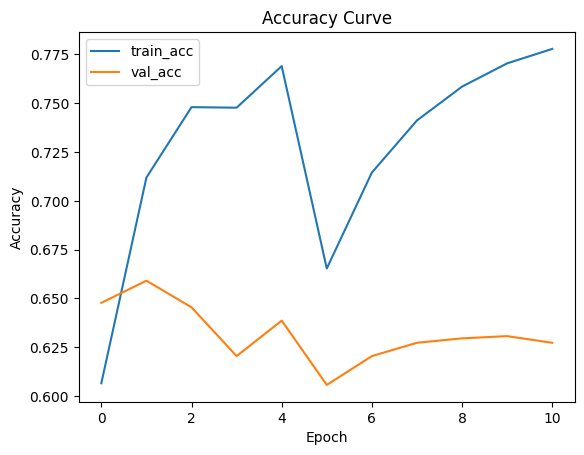

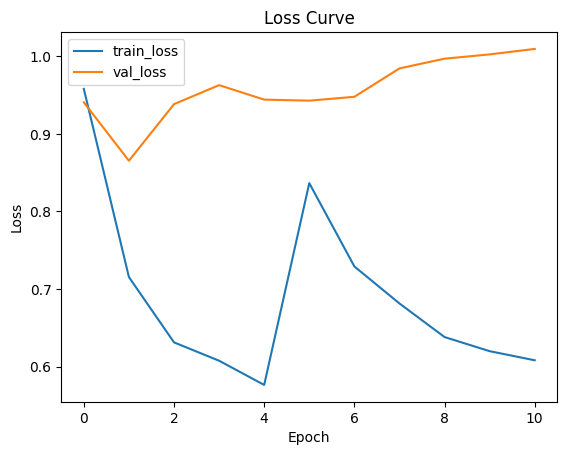

In [ ]:
# 10) Plot Training Curves
# =========================
def plot_curves(h1, h2):
    acc = h1.history.get("accuracy", []) + h2.history.get("accuracy", [])
    val_acc = h1.history.get("val_accuracy", []) + h2.history.get("val_accuracy", [])
    loss = h1.history.get("loss", []) + h2.history.get("loss", [])
    val_loss = h1.history.get("val_loss", []) + h2.history.get("val_loss", [])

    plt.figure()
    plt.plot(acc, label="train_acc")
    plt.plot(val_acc, label="val_acc")
    plt.title("Accuracy Curve")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

    plt.figure()
    plt.plot(loss, label="train_loss")
    plt.plot(val_loss, label="val_loss")
    plt.title("Loss Curve")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

plot_curves(h1, h2)

In [ ]:
# 11) Evaluate on Test Set (same as your TEST folder)
# =========================
test_loss, test_acc = model.evaluate(test_ds, verbose=0)
print(f"\nTest Accuracy: {test_acc:.4f} | Test Loss: {test_loss:.4f}")


Test Accuracy: 0.6057 | Test Loss: 0.9428


In [ ]:
# 12) Predictions
# =========================
y_true = np.concatenate([y.numpy() for _, y in test_ds], axis=0)
y_prob = model.predict(test_ds, verbose=0)
y_pred = np.argmax(y_prob, axis=1)

In [ ]:
# 13) Classification Report
# =========================
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))


Classification Report:
                 precision    recall  f1-score   support

    Anthracnose     0.8500    0.1545    0.2615       220
        Healthy     0.6575    0.9773    0.7861       220
           Scab     0.6055    0.3000    0.4012       220
Styler end root     0.5396    0.9909    0.6987       220

       accuracy                         0.6057       880
      macro avg     0.6632    0.6057    0.5369       880
   weighted avg     0.6632    0.6057    0.5369       880



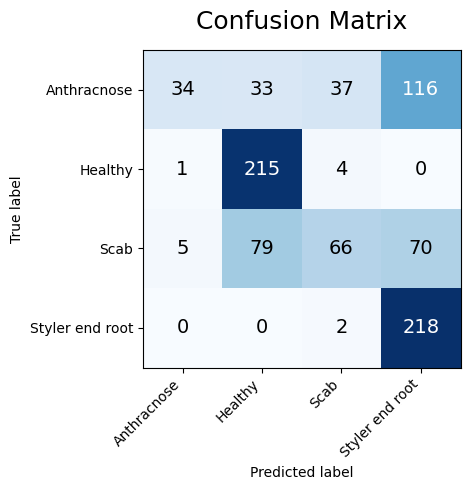

In [ ]:
# 14) Confusion Matrix (EXACT style as provided image)
# =========================
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(7, 5))

# Blue-style matrix (same as your image)
im = ax.imshow(cm, cmap=plt.cm.Blues)

ax.set_title("Confusion Matrix", fontsize=18, pad=15)
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")

ax.set_xticks(range(num_classes))
ax.set_yticks(range(num_classes))
ax.set_xticklabels(class_names, rotation=45, ha="right")
ax.set_yticklabels(class_names)

# Add numbers inside cells
thresh = cm.max() / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(
            j, i, cm[i, j],
            ha="center",
            va="center",
            fontsize=14,
            color="white" if cm[i, j] > thresh else "black"
        )

# ❌ No colorbar (important)
ax.figure.colorbar(im).remove()

ax.grid(False)
plt.tight_layout()
plt.show()


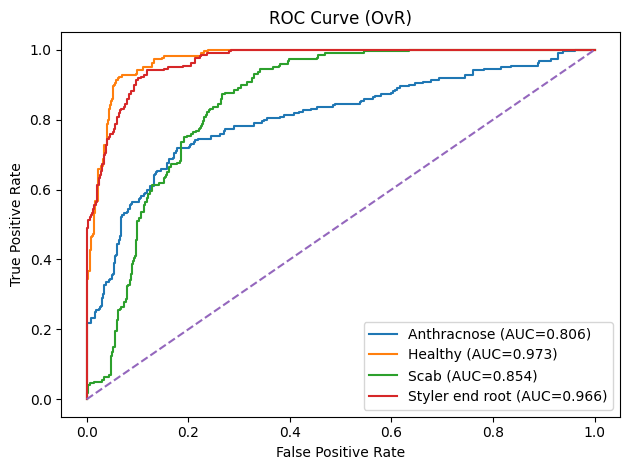

In [ ]:
# 15) ROC Curve (One-vs-Rest)
# =========================
y_true_bin = label_binarize(y_true, classes=list(range(num_classes)))

plt.figure()
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{class_names[i]} (AUC={roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("ROC Curve (OvR)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# 17) Save Model
import os
os.makedirs("/content/drive/MyDrive/Capstone Models", exist_ok=True)

model.save("/content/drive/MyDrive/Capstone Models/EfficientNetB0_fruit.keras")
print("Model saved successfully.")

Model saved successfully.
